# Use the new CLIMADA measure


- Show how the exposure, imapct fucntion set, hazard can be used using the new measure set

Monday (Gör klart manual attribution)
1) make estimated cost and revenue df
- Cost is cost, perhaps incl. added and present 
- revenue today (second, main, total )
- revenue future (second, main, total )
2) set baseline = present
- ... ?

Tuesday
- Gör klart uncertainties

Wed-Thursday 
- New module 

UNcertainties

- Yield-canopy curve
- Cooling curve
- Impact function


## 0 - Initial parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type
hazard_type = 'Tmax' #'VPD' or 'Tmax' (Temperature)

# Define the future scenario ( Use 'plus2C' for 2 degrees Celsius increase for the hazard part)
future_climate_scenario = 'plus2C' # 

# Define the present year and the future year
present_year = 2020
future_year = 2050


## 1 - Crops and Canopy compositions

Store canopy and crop compositions for all sites in data frames

In [2]:
import pandas as pd
from tabulate import tabulate

# get the number of sheets in the Excel file apart from the 'Current' sheet
file = INPUT_DIR / "canopy_crop_composition.xlsx"
canopy_comps = pd.ExcelFile(file).sheet_names

# Create a dictionary to hold the canopy composition data
canopy_crop_dict = {}
for sheet in canopy_comps:
    canopy_crop_dict[sheet] = pd.read_excel(file, sheet_name=sheet)

# Sort the canopy composition data by the 'Latitude' and 'Longitude' columns
for sheet, df in canopy_crop_dict.items():
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        canopy_crop_dict[sheet] = df.sort_values(by=['Latitude', 'Longitude'])

# Modify the DataFrame to match the expected format for Exposures (Perhaps this should done in an early step or manually)
def modify_canopy_crop_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Rename columns
    df.rename(columns={
        "Latitude": "latitude",
        "Longitude": "longitude"
    }, inplace=True)

    # Generate unique site_id
    df["site_id"] = df.groupby(["latitude", "longitude"]).ngroup()

    return df

# Modify the canopy composition dataframes
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = modify_canopy_crop_df(df)



Check that the site ids, species anems are consistent across all options

In [3]:
# Check that all that all the dataframes have the same site_ids matched to  latitude and longitude
# Use the first sheet's mapping as the reference
reference_sheet = list(canopy_crop_dict.keys())[0]
reference_df = canopy_crop_dict[reference_sheet]
reference_mapping = reference_df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)

# Compare with each other sheet
for sheet, df in canopy_crop_dict.items():
    if sheet == reference_sheet:
        continue
    current_mapping = df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)
    
    if not reference_mapping.equals(current_mapping):
        print(f"⚠️ Inconsistent site_id mapping in sheet: {sheet}")
    else:
        print(f"✅ Consistent site_id mapping in sheet: {sheet}")

✅ Consistent site_id mapping in sheet: more_trees
✅ Consistent site_id mapping in sheet: even_more_trees
✅ Consistent site_id mapping in sheet: no_trees


Calculate the canopy crop and tree shade per site

In [4]:
def add_canopy_crop_per_site(df: pd.DataFrame,
                            present_df: pd.DataFrame,
                            max_trees_per_ha: int = 144) -> pd.DataFrame:
    """
    Add per-tree shading, shade contribution, and canopy cover per site.

    Args:
        df (pd.DataFrame): Canopy composition DataFrame to update.
        present_df (pd.DataFrame): Reference sheet (usually 'present') with Per-tree shading (%).
        max_trees_per_ha (int): Maximum number of trees per hectare for normalization.

    Returns:
        pd.DataFrame: Modified DataFrame with canopy_cover and related columns.
    """
    df = df.copy()

    # 1. Merge shading values if not already present
    if 'Per-tree shading (%)' not in df.columns:
        matching_cols = ['site_id', 'Scientific name']
        df = df.merge(
            present_df[matching_cols + ['Per-tree shading (%)']],
            on=matching_cols,
            how='left'
        )

    # 2. Calculate
    df['Per-tree shading (%) scaled'] = df['Per-tree shading (%)']/max_trees_per_ha
    df['Shade contribution (%)'] = df['Per-tree shading (%) scaled'] * df['Plants/ha'] * df['Plot size (ha)']
    df['Tree Shade (%)'] = df.groupby("site_id")['Shade contribution (%)'].transform("sum")
    df['canopy_cover'] = df['Tree Shade (%)']

    return df

import copy
#canopy_crop_shade_dict = copy.deepcopy(canopy_crop_dict)

# Apply function to each sheet
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = add_canopy_crop_per_site(df, canopy_crop_dict['present'])
    print(f"Modified Canopy Composition DataFrame for '{comp}' with Per-tree shading and canopy cover:")
    print(tabulate(canopy_crop_dict[comp], headers='keys', tablefmt='psql'))


Modified Canopy Composition DataFrame for 'present' with Per-tree shading and canopy cover:
+----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+
|    |   latitude |   longitude |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |
|----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-----------------------------

Calculate the added plants for each species 

In [5]:
baseline_df = canopy_crop_dict['present']
alternative_df = canopy_crop_dict['no_trees']

import pandas as pd

import pandas as pd
import numpy as np

def add_plants_diff_column(baseline_df: pd.DataFrame, alternative_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add:
      - 'Added Plants/ha'    = alt - baseline
      - 'Previous Plants/ha' = baseline minus removals (never below 0)
    Match on ['site_id', 'Scientific name'].
    """
    merged = alternative_df.merge(
        baseline_df[["site_id", "Scientific name", "Plants/ha"]],
        on=["site_id", "Scientific name"],
        how="left",
        suffixes=("", "_baseline"),
    )

    # ensure numeric
    for c in ["Plants/ha", "Plants/ha_baseline"]:
        merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(0.0)

    merged["Added Plants/ha"] = merged["Plants/ha"] - merged["Plants/ha_baseline"]

    merged["Previous Plants/ha"] = (
        merged["Plants/ha_baseline"]
            .where(merged["Added Plants/ha"] >= 0,
                   merged["Plants/ha_baseline"] + merged["Added Plants/ha"])
            .clip(lower=0)
    )

    return merged

baseline_df = canopy_crop_dict['present']
for comp, df in canopy_crop_dict.items():
    canopy_crop_dict[comp] = add_plants_diff_column(baseline_df, df)
    print(f"canopy object for {comp}:") 
    print(tabulate(canopy_crop_dict[comp], headers='keys', tablefmt='psql'))

canopy object for present:
+----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+
|    |   latitude |   longitude |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |
|----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------

In [6]:
import pandas as pd

# Import the canopy price data
file = INPUT_DIR / "Crop Price Data.xlsx"
costs_df = pd.read_excel(file, sheet_name="Costs")
revenues_df = pd.read_excel(file, sheet_name="Revenue")

print(f"Costs DataFrame:\n{tabulate(costs_df, headers='keys', tablefmt='grid')}\n")
print(f"Revenues DataFrame:\n{tabulate(revenues_df, headers='keys', tablefmt='grid')}\n")

Costs DataFrame:
+----+------------------------------------+----------------------+-----------------------+--------------------------+--------------------+--------+
|    | Species                            |   Nursery cost (RD$) |   Planting cost (RD$) |   Maintenance cost (RD$) |   Total Cost (RD$) |   Year |
+====+====================================+======================+=======================+==========================+====================+========+
|  0 | Guama (Inga spp.)                  |                   50 |                    25 |                       20 |                 95 |      1 |
+----+------------------------------------+----------------------+-----------------------+--------------------------+--------------------+--------+
|  1 | Cuban Pine Nut (Gliricidia sepium) |                   30 |                    35 |                       20 |                 85 |      1 |
+----+------------------------------------+----------------------+-----------------------+-----

Given that we have no impact function for the fruits we set the value as 0 (Add later somewhere given impact function)

In [7]:
# Update the canopy_crop_dict daat frames so that all rows except Scientific name  Coffea arabica have Price-per-tonnes = np.nan
df = canopy_crop_dict['present']  # Use the 'present' sheet as a reference for Price-per-tonnes
# Set Price-per-tonnes to NaN for all rows except for 'Coffea arabica'
df['Price-per-tonnes'] = df.apply(
    lambda row: row['Price-per-tonnes'] if row['Scientific name'] == 'Coffea arabica' else float('nan'),
    axis=1
        )
# Update the canopy_crop_dict with the modified DataFrame
print(f"Updated Price-per-tonnes for 'present':")
print(tabulate(canopy_crop_dict['present'], headers='keys', tablefmt='psql'))

Updated Price-per-tonnes for 'present':
+----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+
|    |   latitude |   longitude |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |
|----+------------+-------------+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+-------

## 2 - Exposure

### 2.1 - Make the exposure object for the present condition

In [8]:
from climada.entity import Exposures

def make_exposure_from_canopy_df(canopy_df: pd.DataFrame, value_unit: str = "USD") -> Exposures:
    """
    Create an Exposures object from a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing exposure data.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """

    # Store the modified DataFrame for 'present' as a reference
    exp_df = canopy_df.copy()

    # 1. Calculate production and the value of the crops
    exp_df["Production (t)"] = exp_df["Plot size (ha)"] * exp_df["Yield (t/ha/year)"]
    exp_df["value"] = exp_df["Production (t)"]*exp_df["Price-per-tonnes"]

    # Ensure the DataFrame has the required columns
    required_cols = ['site_id', 'latitude', 'longitude', 'canopy_cover', 'Production (t)', 'value']
    if not all(col in exp_df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain the following columns: {required_cols}")
    
    # Set any rows with NaN in the value column to zero
    exp_df['value'].fillna(0, inplace=True)

    # Create Exposures object
    exp = Exposures(exp_df)
    exp.value_unit = value_unit
    exp.check()
    
    return exp

Make the exposure of the present composition

In [9]:
# Parameters for the exposure
exp_present = make_exposure_from_canopy_df(canopy_df=canopy_crop_dict['present'],
                                            value_unit = "USD")

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

2025-08-11 23:12:32,700 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposures object for 'present' condition:
+----+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+------------------+---------+----------------------------------------------+
|    |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   Production (t) |   value | g

### 2.2 - Adjust the yield given the Canopy

Show the yield vs canopy cover curve

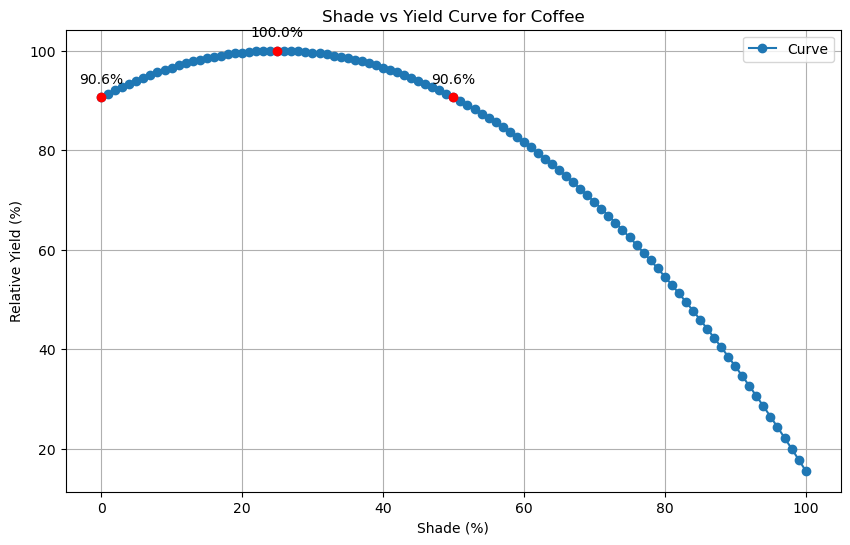

In [10]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Load curve
shade_vs_yield_curve_file = INPUT_DIR / "Shade_vs_Yield_Curve.csv"
shade_vs_yield_curve_COFFE = pd.read_csv(shade_vs_yield_curve_file)

# Interpolator
f_interp = interp1d(
    shade_vs_yield_curve_COFFE['Shade (%)'],
    shade_vs_yield_curve_COFFE['Yield (%)'],
    kind='linear',
    fill_value='extrapolate'
)

# Points of interest
shade_points = [0, shade_vs_yield_curve_COFFE.loc[shade_vs_yield_curve_COFFE['Yield (%)'].idxmax(), 'Shade (%)'], 50]
yield_points = [float(f_interp(s)) for s in shade_points]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(shade_vs_yield_curve_COFFE['Shade (%)'], shade_vs_yield_curve_COFFE['Yield (%)'], marker='o', label='Curve')

# Annotate points
for s, y in zip(shade_points, yield_points):
    plt.scatter(s, y, color='red', zorder=5)
    plt.annotate(f"{y:.1f}%", (s, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Shade vs Yield Curve for Coffee')
plt.xlabel('Shade (%)')
plt.ylabel('Relative Yield (%)')
plt.grid()
plt.legend()
plt.show()


Derive a fuction that modifies the yield gien the canopy

In [11]:
from scipy.interpolate import interp1d

def estimate_new_yield(
    current_shade: float,
    current_yield: float,
    new_shade: float,
    shade_yield_df: pd.DataFrame
) -> float:
    """
    Estimate new yield based on change in shade, using relative scaling
    from the provided empirical shade–yield curve DataFrame.

    Args:
        current_shade (float): Current shade (%) [0–100]
        current_yield (float): Current observed yield (any unit)
        new_shade (float): Target new shade (%)
        shade_yield_df (pd.DataFrame): DataFrame with columns 'Shade (%)' and 'Yield (%)'

    Returns:
        float: Estimated new yield
    """
    interpolate_yield = interp1d(
        shade_yield_df["Shade (%)"],
        shade_yield_df["Yield (%)"],
        kind='linear',
        fill_value="extrapolate"
    )
    current_yield_pct = interpolate_yield(current_shade)
    new_yield_pct = interpolate_yield(new_shade)
    
    return current_yield * (new_yield_pct / current_yield_pct)


In [12]:
# Defeine a partial function to estimate new yield for coffee
from functools import partial
estimate_new_yield_coffe = partial(estimate_new_yield, 
                                    shade_yield_df = shade_vs_yield_curve_COFFE) 

# Example usage
current_shade = 50.0  # Current shade in %
current_yield = 1.0  # Current yield in kg/ha
new_shade = 30.0  # New target shade in %
new_yield = estimate_new_yield_coffe(current_shade, current_yield, new_shade)
print(f"Previous yield: {current_yield:.2f} kg/ha with {current_shade}% shade")
print(f"Estimated new yield: {new_yield:.2f} kg/ha with {new_shade}% shade")

Previous yield: 1.00 kg/ha with 50.0% shade
Estimated new yield: 1.10 kg/ha with 30.0% shade


Adjust the new yield given the canopy change

In [13]:
def adjust_yield_based_on_new_canopy_cover(
    prev_crop_df: pd.DataFrame,
    new_crop_df: pd.DataFrame,
    spec_to_fcn: dict  # {str or list[str]: function}
) -> pd.DataFrame:
    """
    Adjust yield in new_crop_df based on canopy cover and scientific name-specific rules.

    Args:
        prev_crop_df (pd.DataFrame): DataFrame with previous canopy cover and yield.
        new_crop_df (pd.DataFrame): DataFrame to adjust.
        spec_to_fcn (dict): Dictionary where keys are scientific name(s) (str or list),
                            and values are functions that estimate new yield.

    Returns:
        pd.DataFrame: DataFrame with adjusted yield values.
    """
    df = new_crop_df.copy()

    # Merge previous yield and canopy cover
    matching_cols = ['site_id', 'Scientific name']
    df = df.merge(
        prev_crop_df[matching_cols + ['canopy_cover', 'Yield (t/ha/year)', 'Price-per-tonnes']],
        on=matching_cols,
        how='left',
        suffixes=('', '_previous')
    )

    df['Yield (t/ha/year)_previous'] = df['Yield (t/ha/year)']

    # Flatten the dictionary to {individual name: function}
    name_to_function = {}
    for names, func in spec_to_fcn.items():
        if isinstance(names, str):
            names = [names]
        for name in names:
            name_to_function[name] = func

    # Apply yield adjustment row-wise
    def compute_new_yield(row):
        name = row['Scientific name']
        func = name_to_function.get(name)
        if func and pd.notna(row['canopy_cover_previous']) and pd.notna(row['canopy_cover']) and pd.notna(row['Yield (t/ha/year)_previous']):
            return func(
                current_shade=row['canopy_cover_previous'],
                current_yield=row['Yield (t/ha/year)_previous'],
                new_shade=row['canopy_cover']
            )
        return row['Yield (t/ha/year)_previous']

    df['Yield (t/ha/year)'] = df.apply(compute_new_yield, axis=1)

    return df


In [14]:
# Example usage of the adjust_yield_based_on_new_canopy_cover function with multiple species
prev_crop_df = canopy_crop_dict['present']  # Assuming 'present' is the previous crop DataFrame
new_crop_df = canopy_crop_dict[list(canopy_crop_dict.keys())[1]]  # Using the second sheet as the new crop DataFrame
spec_to_fcn = {
    'Coffea arabica': estimate_new_yield_coffe,
    'Coffea canephora': estimate_new_yield_coffe,
    'Coffea liberica': estimate_new_yield_coffe,
    'Coffea excelsa': estimate_new_yield_coffe,
    'Theobroma cacao': estimate_new_yield_coffe  # Assuming the same function for cacao
}
updated_df = adjust_yield_based_on_new_canopy_cover(
    prev_crop_df=prev_crop_df,
    new_crop_df=new_crop_df,
    spec_to_fcn=spec_to_fcn
)

print("Updated new crop DataFrame with adjusted yields for multiple species:")
print(tabulate(updated_df, headers='keys', tablefmt='psql'))

Updated new crop DataFrame with adjusted yields for multiple species:
+----+------------+-------------+-----------------+------------------+----------+--------------------+--------------------+-----------+-------------+-----------+------------------------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------------------+---------------------+--------------------+------------------------------+
|    |   latitude |   longitude |   Elevation (m) |   Plot size (ha) | System   | Species            | Scientific name    | Role      |   Plants/ha |   site_id |   Per-tree shading (%) |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   canopy_cover_previous |   Yield (t/ha/year) |   Price-per-tonnes |   Yield (t/ha/year)_previous |
|----+------------+-------------+-

Update the make the exposure function

In [15]:
def make_exposures(canopy_df, exposure_present=None, spec_to_fcn=spec_to_fcn, value_unit="USD"):
    """
    Create an Exposures object from a canopy DataFrame.

    Args:
        canopy_df (pd.DataFrame): DataFrame containing canopy data.
        base_exposures (Exposures): Base exposures to use for the new exposures.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """
    
    if exposure_present is None:
        # If no base exposures are provided, create a new Exposures object
        exp = make_exposure_from_canopy_df(canopy_df, value_unit=value_unit)
    else:
        # Use the base exposures and update the DataFrame
        new_canopy_df = canopy_df.copy()
        prev_canopy_df = exposure_present.gdf.copy()
        updated_df = adjust_yield_based_on_new_canopy_cover(
            prev_crop_df=prev_canopy_df,
            new_crop_df=new_canopy_df,
            spec_to_fcn=spec_to_fcn
        )
        exp = make_exposure_from_canopy_df(updated_df, value_unit=value_unit)
            
    return exp


### 2.3 Now we have a fcuntion changing the exposure and given 

- exposure_present
- spec_to_fcn=spec_to_fcn, 
- value_unit="USD"

Show how you could make the current and alternative exposures

In [16]:
# Make the exposures for the 'present' condition
exp_present = make_exposures(canopy_df=canopy_crop_dict['present'],
                         exposure_present= None,
                         spec_to_fcn=spec_to_fcn, 
                         value_unit="USD")

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# Make the exposures for the second condition (e.g., 'future' or 'alternative')
alternative_name = list(canopy_crop_dict.keys())[1]  # Use the second condition
exp_new = make_exposures(canopy_df=canopy_crop_dict[alternative_name],
                         exposure_present=exp_present,
                         spec_to_fcn=spec_to_fcn, 
                         value_unit="USD")
print(f"Exposures object for {alternative_name} condition:")
print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))

2025-08-11 23:12:32,902 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
Exposures object for 'present' condition:
+----+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+------------------+---------+----------------------------------------------+
|    |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   Production (t) |   value | g

## 3 – Hazard 


- Here we do it a little bit differetn then the common CLIMADA as each grid point has a uniquiew adaption measure given by the canopy level.
- We will need to store a current and a future hazard set which will be usefulle for the risk comaprisson over time and the CB analysis.
- We download both historical weather and future weather (which can be changed based on RCP levels)

Download the data 

https://www.climatologylab.org/terraclimate.html

🌡️ VPD – Vapour Pressure Deficit

We model Vapour Pressure Deficit (VPD) as a key climate hazard, similar to the paper Kath et al. (2022), Nature Food. The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts for coffee.

We calculate the mean VPD over the crop-specific growing season: Mexico: June to December

📂 Loading 37 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
📂 Loading 30 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...


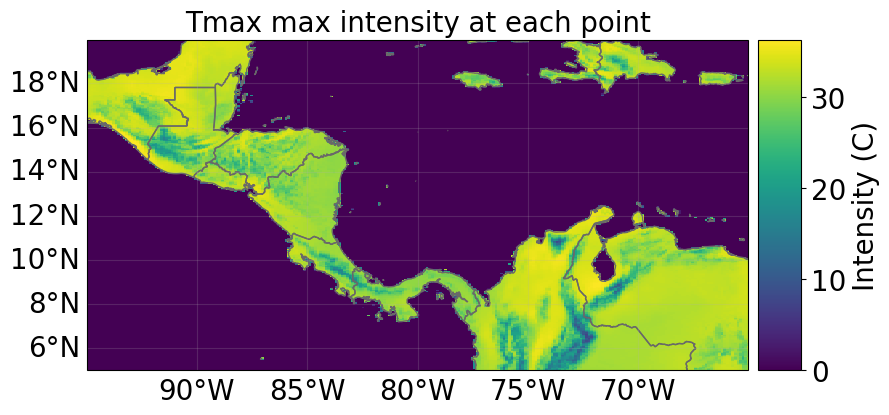

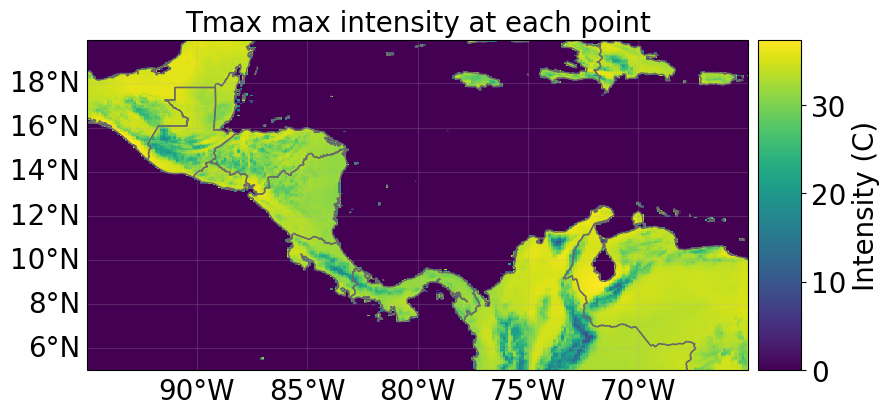

In [17]:
from utils_cb import create_hazard_from_nc_files
from climada.hazard import Hazard

# Determine the corresponding parameters for the hazard type
nc_files = {'today': [], 'future': []}
haz_dict = {'today': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg = 'mean'
    varname = 'vpd'
    nc_files['today'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_vpd_*_CA.nc"))
    units = 'kPa'
    months = [5, 6, 7, 8, 9, 10, 11]  # April to November
elif hazard_type == 'Tmax':
    agg = 'mean'
    varname = 'tmax'
    nc_files['today'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_tmax_*_CA.nc"))
    units = 'C'
    months = [5, 6, 7, 8, 9, 10, 11] # April to November


# Store the hazard type and parameters in a dictionary
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
                        nc_files[key],
                        varname=varname,
                        haz_type=hazard_type,
                        units=units,
                        agg=agg,
                        months=months,
                        nan_replacement=0.0  # Use NaN to keep sparse matrix
                    )
    # Plot the hazard object
    haz_dict[key].plot_intensity(0)


## 4 – Impact function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8)


### 4.1 – Get the default impact functions

Index: 0, Value: 0.18126924692201807
Intensity: [0.18126925 0.09516258 0.         0.25918178 0.5034147 ]
Index: 1, Value: 0.09516258196404037
Intensity: [0.         0.09516258 0.         0.25918178 0.5034147 ]
Index: 2, Value: 0.0
Intensity: [0.         0.         0.         0.25918178 0.5034147 ]
2025-08-11 23:13:15,068 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


array([<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
       <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
      dtype=object)

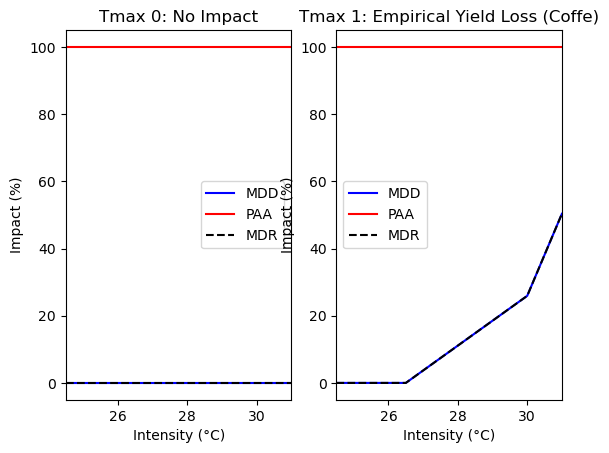

In [18]:
from utils_cb import impact_func_from_kath

import pandas as pd
import numpy as np
from climada.entity import ImpactFunc, ImpactFuncSet


# Create an ImpactFuncSet with the VPD impact function
imp_fun_set_base = ImpactFuncSet()

## Make the impact function for coffee with id 1 
# Coffe has id # 1, Banana has id 2, Cacao has id 3
if hazard_type.upper() == 'TMAX':
    impf_coffe = impact_func_from_kath(
        file_path= "tasmax_effect_approximation.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="Tmax",
        unit="°C",
        if_id= 1,
        name="Empirical Yield Loss (Coffe)"
    )
elif hazard_type.upper() == 'VPD':
    impf_coffe = impact_func_from_kath(
        file_path= "vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="VPD",
        unit="kPa",
        if_id= 1,
        name="Empirical Yield Loss (Coffe)"
    )

#impf_coffe.plot()

# Adjust the impact function intensity to be zero before the increa
for idx, value in enumerate(impf_coffe.mdd):
    print(f"Index: {idx}, Value: {value}")
    print(f"Intensity: {impf_coffe.mdd}")
    if value > 0:
        impf_coffe.mdd[idx] = 0.0
    else:
        break

#impf_coffe.plot()

## Make the non impact function for coffee with id 0
impf_zero = copy.deepcopy(impf_coffe)
impf_zero.id = 0  # Set the ID to 0 for no impact
impf_zero.name = "No Impact"
impf_zero.mdd = np.zeros_like(impf_coffe.mdd)  # Set all values to zero
#impf_zero.plot()

# Add the impact function to the ImpactFuncSet
imp_fun_set_base.append(impf_zero)
imp_fun_set_base.append(impf_coffe)

# Plot the impact function set
imp_fun_set_base.plot()


In [19]:
# Make a dictionary to hold the default impact function IDs with 0 being no imact and 1 being for coffee and 2 for cacao
# 0 would be for Inga spp., Citrus aurantium, Citrus sinensis, Pouteria sapota, Artocarpus altilis, Persea americana
default_impact_function_id = {0: ['Inga spp.', 'Citrus aurantium', 'Citrus sinensis', 'Pouteria sapota', 'Artocarpus altilis', 'Persea americana', 'Theobroma cacao'],
                              1: ['Coffea arabica', 'Coffea canephora', 'Coffea liberica', 'Coffea excelsa']
                              #2: ['Theobroma cacao']}
                            }

# Flatten to list of (Scientific name, impf_id_default)
records = [
    {'Scientific name': species, 'impf_id_default': impf_id}
    for impf_id, species_list in default_impact_function_id.items()
    for species in species_list
]

# Create DataFrame
impf_default_df = pd.DataFrame(records)
print("Default Impact Function DataFrame:")
print(tabulate(impf_default_df, headers='keys', tablefmt='psql'))

Default Impact Function DataFrame:
+----+--------------------+-------------------+
|    | Scientific name    |   impf_id_default |
|----+--------------------+-------------------|
|  0 | Inga spp.          |                 0 |
|  1 | Citrus aurantium   |                 0 |
|  2 | Citrus sinensis    |                 0 |
|  3 | Pouteria sapota    |                 0 |
|  4 | Artocarpus altilis |                 0 |
|  5 | Persea americana   |                 0 |
|  6 | Theobroma cacao    |                 0 |
|  7 | Coffea arabica     |                 1 |
|  8 | Coffea canephora   |                 1 |
|  9 | Coffea liberica    |                 1 |
| 10 | Coffea excelsa     |                 1 |
+----+--------------------+-------------------+


### 4.2 Add the mapped impact function ids to the exposure (update the function)

In [20]:
# make the map id and attache it to an exposure

In [21]:
import copy
import numpy as np
import pandas as pd
from tabulate import tabulate

def generate_custom_impact_function_IDs_by_canopy_df(
    impf_default_df: pd.DataFrame,
    canopy_df: pd.DataFrame,
    hazard_type: str,
    ignore_impf_ids: list = [0] # Default to ignoring ID 0 (no impact) if not specified
):
    """
    Generate custom impact function IDs based on canopy cover and assign new IDs.

    Args:
        impf_default_df (pd.DataFrame): Columns ['Scientific name', 'impf_id_default']
        canopy_df (pd.DataFrame): Columns ['site_id', 'Scientific name', 'canopy_cover']
        imp_fun_set (ImpactFuncSet): Base impact function set to copy and expand.
        adjust_fcn (function): Function to adjust the base impact function using canopy_cover.
        hazard_type (str): Hazard type (e.g. "TR").
        ignore_impf_ids (list): List of impf IDs to skip (default: [0] = no impact)

    Returns:
        Tuple[pd.DataFrame, ImpactFuncSet]: 
            - Updated DataFrame with new impact function column `impf_{hazard_type}`
            - Modified ImpactFuncSet with newly added functions
    """

    # get the site_id and scientific name from the canopy_df
    df_site_canopy = canopy_df[['site_id', 'Scientific name']].drop_duplicates()

    # Merge canopy and default impact function assignments
    df_impf_id_map = df_site_canopy.merge(impf_default_df, on='Scientific name', how='left')

    # Copy the impact function set
    #imp_fun_set_new = copy.deepcopy(imp_fun_set)

    # Get next available ID
    next_id = impf_default_df['impf_id_default'].max() + 1

    # For caching and reuse
    species_func_cache = {}

    # Store new IDs
    new_impf_ids = []

    for _, row in df_impf_id_map.iterrows():
        site_id = row['site_id']
        species_name = row['Scientific name']
        base_impf_id = row['impf_id_default']

        if pd.isna(base_impf_id) or base_impf_id in ignore_impf_ids:
            # Use original base ID (e.g. 0 = no impact)
            new_impf_ids.append(base_impf_id)
            continue

        # Use a cache key (species, base ID) to avoid duplication
        key = (site_id, species_name, base_impf_id)

        if key in species_func_cache:
            new_impf_ids.append(species_func_cache[key])
            continue

        # Get base function and generate adjusted one
        species_func_cache[key] = next_id
        new_impf_ids.append(next_id)
        next_id += 1

    # Assign new column to the DataFrame
    df_impf_id_map = df_impf_id_map.copy()
    impf_col_name = f"impf_{hazard_type}"
    df_impf_id_map[impf_col_name] = new_impf_ids


    return df_impf_id_map

Test the function

In [22]:
# Example usage
df_impf_id_map = generate_custom_impact_function_IDs_by_canopy_df(
    impf_default_df=impf_default_df,
    canopy_df= canopy_crop_dict['present'],
    hazard_type=hazard_type
)

# Print the DataFrame with new impact function IDs
print("DataFrame with new impact function IDs:")
print(tabulate(df_impf_id_map, headers='keys', tablefmt='psql'))

DataFrame with new impact function IDs:
+----+-----------+--------------------+-------------------+-------------+
|    |   site_id | Scientific name    |   impf_id_default |   impf_Tmax |
|----+-----------+--------------------+-------------------+-------------|
|  0 |         0 | Coffea arabica     |                 1 |           2 |
|  1 |         0 | Inga spp.          |                 0 |           0 |
|  2 |         0 | Citrus aurantium   |                 0 |           0 |
|  3 |         0 | Citrus sinensis    |                 0 |           0 |
|  4 |         0 | Pouteria sapota    |                 0 |           0 |
|  5 |         0 | Artocarpus altilis |                 0 |           0 |
|  6 |         0 | Persea americana   |                 0 |           0 |
|  7 |         1 | Coffea arabica     |                 1 |           3 |
|  8 |         1 | Inga spp.          |                 0 |           0 |
|  9 |         1 | Citrus aurantium   |                 0 |           0 

Add the impf_Tmax to the exposure id for each canopy

In [23]:
def make_exposures_from_canopy_df(
    canopy_df: pd.DataFrame,
    exposure_present: Exposures = None,
    spec_to_fcn: dict = None,
    value_unit: str = "USD",
    impf_default_df=impf_default_df,
    ignore_impf_ids=[0],
    hazard_type: str = hazard_type
) -> Exposures:
    """
    Create an Exposures object from a canopy DataFrame.

    Args:
        canopy_df (pd.DataFrame): DataFrame containing canopy data.
        exposure_present (Exposures): Base exposures to use for the new exposures.
        spec_to_fcn (dict): Dictionary where keys are scientific name(s) (str or list),
                            and values are functions that estimate new yield.
        value_unit (str): Unit of value for the exposures.

    Returns:
        Exposures: An Exposures object with the provided data.
    """

    # Get the custom impact function IDs from the canopy DataFrame
    df_impf_id_map = generate_custom_impact_function_IDs_by_canopy_df(
        impf_default_df=impf_default_df,
        canopy_df=canopy_df,
        hazard_type=hazard_type,
        ignore_impf_ids= ignore_impf_ids
    )
    # Add to the canopy DataFrame
    canopy_df = canopy_df.merge(df_impf_id_map[['site_id', 'Scientific name', f'impf_{hazard_type}']],
                                 on=['site_id', 'Scientific name'],
                                 how='left')

    # make the exposures
    exp = make_exposures(
        canopy_df=canopy_df,
        exposure_present=exposure_present,
        spec_to_fcn=spec_to_fcn,
        value_unit=value_unit
    )

    return exp


Not that we only use the default values parameters (consider creating partials)

In [24]:
# Example usage 
exp_present = make_exposures_from_canopy_df(canopy_df = canopy_crop_dict['present'],
                                            exposure_present= None,
                                            spec_to_fcn = spec_to_fcn)

# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

Exposures object for 'present' condition:
+----+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+----------------------------------------------+
|    |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   impf_Tmax |   Production (t) |   value | geometry                                     |
|----+-----------------+----------+---------------

### 4.3 Adjust the impact function given the cooling and make unique impact function sets

Make the adjustment function

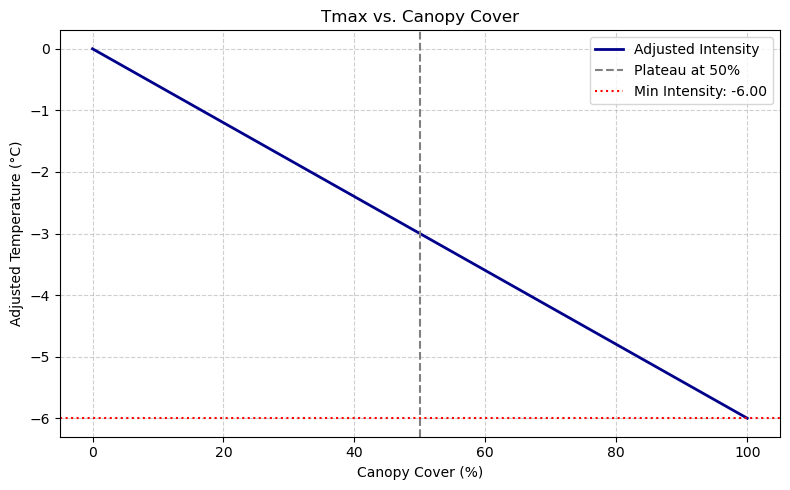

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Updated function definition
def helper_create_adj_func(max_cooling=6, plateau_at=100, sensitivity=None):
    """
    Creates an adjustment function for canopy cover effects on the intensity of a hazard.
    Args:
        max_cooling (float): Maximum cooling effect (°C or kPa).
        plateau_at (float): Canopy cover percentage at which the cooling effect plateaus.
        sensitivity (float, optional): Sensitivity factor for VPD reduction. If None, no
            sensitivity adjustment is applied.
    Returns:
        function: A function that takes a hazard intensity and canopy cover array
                  and returns the adjusted hazard intensity.
    """
    slope = -max_cooling / plateau_at

    def adjustment(intensity, canopy_cover):
        """Applies adjustment to hazard intensity based on canopy cover."""
        if not isinstance(canopy_cover, np.ndarray):
            canopy_cover = np.array(canopy_cover)
        canopy = np.clip(canopy_cover, 0, 100)
        temp_reduction = np.where(
            canopy <= plateau_at,
            slope * canopy,
            -max_cooling
        )
        if sensitivity is not None:
            reduction = -sensitivity * temp_reduction
        else:
            reduction = temp_reduction
        return intensity + reduction

    return adjustment

# Example for plotting
canopy = np.linspace(0, 100, 200)

if hazard_type.upper() == 'TMAX':
    base_intensity = 0  # °C
    adjust_fcn = helper_create_adj_func()
    ylabel = "Adjusted Temperature (°C)"
    title = "Tmax vs. Canopy Cover"
elif hazard_type.upper() == 'VPD':
    base_intensity = 0  # kPa
    adjust_fcn = helper_create_adj_func(sensitivity=0.15)
    ylabel = "Adjusted VPD (kPa)"
    title = "VPD vs. Canopy Cover"
else:
    raise ValueError("Unsupported hazard type")

# Calculate adjusted values
adj_intensity = adjust_fcn(base_intensity, canopy)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, adj_intensity, label="Adjusted Intensity", color="darkblue", linewidth=2)
plt.axvline(50, linestyle='--', color='gray', label="Plateau at 50%")
plt.axhline(adj_intensity[-1], linestyle=':', color='red', label=f'Min Intensity: {adj_intensity[-1]:.2f}')
plt.title(title)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
# Suppose you already have:
# - impf: the original impact function
# - adjust_fcn: a function like adjust_fcn(intensity, canopy)

import numpy as np
import copy

def adjust_impf_by_canopy(impf, adjust_fcn, new_id, current_canopy=50, new_name=None):
    """
    Adjust an impact function based on a canopy adjustment function.

    Parameters:
    -----------
    impf : ImpactFuncSet or compatible object
        Original impact function to be adjusted.
    adjust_fcn : function
        Function that modifies intensity based on canopy cover: f(intensity, canopy).
    new_id : int
        ID for the new adjusted impact function.
    current_canopy : float
        Canopy cover percentage to apply (default is 50).

    Returns:
    --------
    adj_impf : ImpactFunc object
        A copy of the original impact function with adjusted intensity and MDR.
    """
    # Copy the original impact function
    adj_impf = copy.deepcopy(impf)

    # Full original intensity range
    orig_intensity = impf.intensity
    orig_min, orig_max = orig_intensity.min(), orig_intensity.max()

    # Use fine spacing to assess max shift
    test_intensity = np.linspace(orig_min, orig_max, 500)
    adjusted = adjust_fcn(test_intensity, current_canopy)
    shift = adjusted - test_intensity
    max_shift = np.abs(shift).max()

    # Extend range to ensure coverage
    n_points = 50
    intensity_range = np.linspace(orig_min - max_shift, orig_max + max_shift, n_points)


    # Check paa logic
    if np.all(impf.paa == 1):
        adj_intensity = adjust_fcn(intensity_range, current_canopy)
        adjusted_mdr = impf.calc_mdr(adj_intensity)

        # Update impact function
        adj_impf.intensity = intensity_range
        adj_impf.mdd = adjusted_mdr
        adj_impf.paa = np.ones_like(intensity_range)
        adj_impf.id = new_id
        if new_name is not None:
            adj_impf.name = new_name

    else:
        print('⚠️ Warning: impf.paa is not all ones, adjustment skipped.')

    return adj_impf


Demonstrate the adjusted imapct function

<Axes: title={'center': 'Tmax 1: Adjusted Impact Function (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>

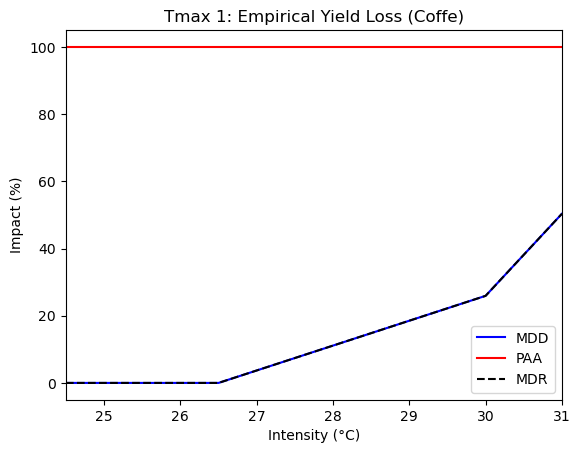

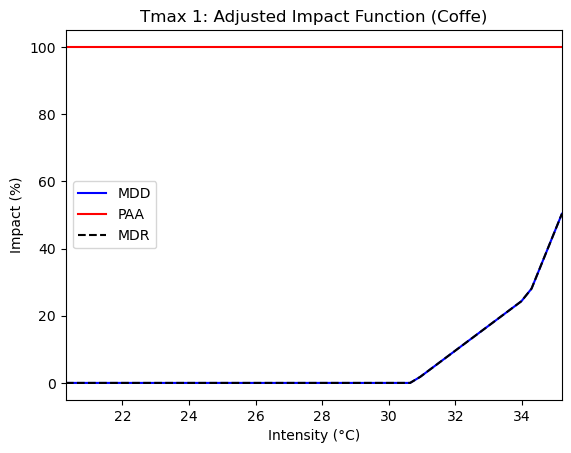

In [27]:
new_id = 1
adj_impf = adjust_impf_by_canopy(impf_coffe, adjust_fcn, new_id, current_canopy=70, new_name="Adjusted Impact Function (Coffe)")

impf_coffe.plot()
adj_impf.plot()

Make a unique impact function set for each canopy composition

In [28]:
def create_adjusted_impact_function_set(
    canopy_df: pd.DataFrame,
    adjust_fcn,
    imp_fun_set_base: ImpactFuncSet = imp_fun_set_base,
    df_impf_id_map: pd.DataFrame = df_impf_id_map,
    hazard_type: str = hazard_type,
    ignore_impf_ids: list = [0]  # Default to ignoring ID 0 (no impact) if not specified
):
    """
    Create adjusted impact functions using pre-assigned IDs and canopy cover.

    Args:
        df_impf_id_map (pd.DataFrame): Must contain ['site_id', 'Scientific name', 'impf_id_default', 'impf_{hazard_type}']
        df_site_canopy (pd.DataFrame): Must contain ['site_id', 'Scientific name', 'canopy_cover']
        imp_fun_set_base (ImpactFuncSet): Original function set.
        adjust_fcn (function): Canopy adjustment function.
        hazard_type (str): Hazard type (e.g., "TMAX")

    Returns:
        ImpactFuncSet: New ImpactFuncSet with adjusted functions added.
    """
    # get the site_id and scientific name from the canopy_df
    df_site_canopy = canopy_df[['site_id', 'Scientific name', 'canopy_cover']].drop_duplicates()


    # Merge canopy cover into the ID mapping DataFrame
    df_merged = df_impf_id_map.merge(
        df_site_canopy,
        on=['site_id', 'Scientific name'],
        how='left'
    )

    # Copy original function set
    imp_fun_set_new = copy.deepcopy(imp_fun_set_base)
    seen_ids = set()

    # Iterate through the merged DataFrame to create adjusted functions
    for _, row in df_merged.iterrows():
        site_id = row['site_id']
        base_id = row['impf_id_default']
        new_id = row[f'impf_{hazard_type}']
        canopy = row['canopy_cover']


        if pd.isna(new_id) or new_id in ignore_impf_ids or new_id in seen_ids:
            # Skip if no new ID or already seen
            continue

        base_impf = imp_fun_set_base.get_func(hazard_type, base_id) # Get the base impact function by hazard type and ID
        adjusted_func = adjust_impf_by_canopy(
            base_impf,
            adjust_fcn=adjust_fcn,
            new_id=new_id,
            current_canopy=canopy, 
            new_name=f"{row['Scientific name']} site {site_id}"
        )

        imp_fun_set_new.append(adjusted_func)
        seen_ids.add(new_id)

    return imp_fun_set_new

Again we might use the partials

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 2: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 3: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>]],
      dtype=object)

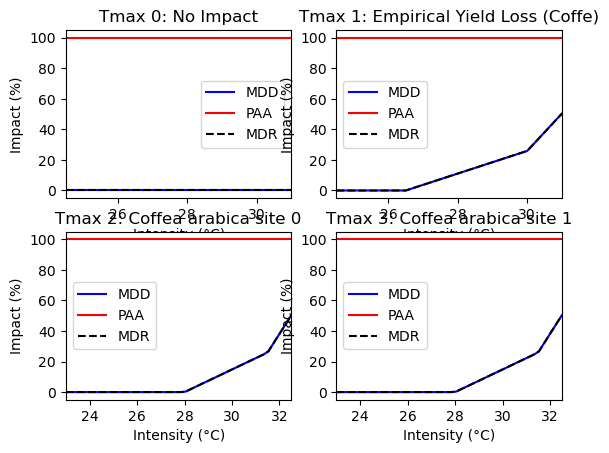

In [29]:
adjusted_impf_set = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict[list(canopy_crop_dict.keys())[0]],  # Use the first sheet as the base
    adjust_fcn=adjust_fcn
)

adjusted_impf_set.plot()

## 5 - Cost and Income

### 5.1 - Costs and Income calculations

In [30]:
# from sre_constants import IN
# import pandas as pd

# # Costs dictionary in RD$
# costs_dict = {
#     "Inga spp.": {"Planting cost": 75, "Maintenance cost": 75},
#     "Citrus aurantium": {"Planting cost": 55, "Maintenance cost": 30},
#     "Citrus sinensis": {"Planting cost": 55, "Maintenance cost": 30},
#     "Pouteria sapota": {"Planting cost": 75, "Maintenance cost": 30},
#     "Artocarpus altilis": {"Planting cost": 65, "Maintenance cost": 50},
#     "Persea americana": {"Planting cost": 55, "Maintenance cost": 30},
#     "Coffea arabica": {"Planting cost": 0, "Maintenance cost": 0},
# }

# # Convert to USD by dividing by 50
# costs_df_usd = (
#     pd.DataFrame.from_dict(costs_dict, orient="index")
#       .reset_index()
#       .rename(columns={"index": "Scientific name"})
# )

# costs_df_usd[["Planting cost", "Maintenance cost"]] = (
#     costs_df_usd[["Planting cost", "Maintenance cost"]] / 50
# ).round(2)

# print(tabulate(costs_df_usd, headers='keys', tablefmt='psql'))

# # Save the costs DataFrame to an Excel file
# output_file = INPUT_DIR / "canopy_costs.xlsx"
# costs_df_usd.to_excel(output_file, index=False, sheet_name="Costs")


Make a detailed cost income calculation

In [31]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def make_cashflows_costs(canopy_df: pd.DataFrame,
                         costs_df: pd.DataFrame,
                         start_year: int = present_year,
                         future_year: int = future_year,
                         disc_rate=None):
    """
    Build yearly cost cashflows (USD) with columns: year | Previous | Added | total.
    If `disc_rate` (object with .net_present_value(start_year, end_year, cashflows)) is given,
    returns (df, npv). Otherwise returns df.
    """

    # Calculate the number of years
    years = future_year - start_year + 1

    need_canopy = {"Scientific name", "Previous Plants/ha", "Added Plants/ha"}
    if not need_canopy.issubset(canopy_df.columns):
        raise ValueError(f"canopy_df must contain columns {need_canopy}")

    need_costs = {"Scientific name", "Planting cost", "Maintenance cost"}
    if not need_costs.issubset(costs_df.columns):
        raise ValueError(f"costs_df must contain columns {need_costs}")

    # Aggregate counts per scientific name
    counts = (canopy_df
              .groupby("Scientific name", as_index=False)[["Previous Plants/ha", "Added Plants/ha"]]
              .sum())

    # Ensure numeric + clip negatives for 'Added'
    counts["Previous Plants/ha"] = pd.to_numeric(counts["Previous Plants/ha"], errors="coerce").fillna(0.0)
    counts["Added Plants/ha"]    = pd.to_numeric(counts["Added Plants/ha"], errors="coerce").fillna(0.0).clip(lower=0)

    # Join costs
    df = counts.merge(costs_df, on="Scientific name", how="left")
    for c in ["Planting cost", "Maintenance cost"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    # Per-year totals
    previous_per_year     = float((df["Previous Plants/ha"] * df["Maintenance cost"]).sum())
    added_maint_per_year  = float((df["Added Plants/ha"]    * df["Maintenance cost"]).sum())
    added_oneoff_year1    = float((df["Added Plants/ha"]    * df["Planting cost"]).sum())

    years_idx = np.arange(start_year, start_year + years)

    previous = np.full(years, round(previous_per_year, 2))
    added    = np.full(years, round(added_maint_per_year, 2))
    if years > 0:
        added[0] = round(added[0] + added_oneoff_year1, 2)

    out = pd.DataFrame({
        "year": years_idx,
        "Previous": previous,
        "Added": added,
    })
    out["total"] = (out["Previous"] + out["Added"]).round(2)

    # Calculate NPV
    npv_dict = {}
    for col in ["Previous", "Added", "total"]:
        if disc_rate is None:
                npv_dict[col] = out[col].sum()
        else:
            npv_dict[col] = disc_rate.net_present_value(int(out["year"].min()),
                                            int(out["year"].max()),
                                            out[col].to_numpy())
    return out, npv_dict

In [32]:
# Import the canopy price data
file = INPUT_DIR / "canopy_costs.xlsx"
costs_df = pd.read_excel(file, sheet_name="Costs")

for comp, df in canopy_crop_dict.items():
    cost_cashflows_df, npv_dict = make_cashflows_costs(df, costs_df)
    print(f"Cashflows for '{comp}':")
    print(tabulate(cost_cashflows_df, headers='keys', tablefmt='psql'))
    print(f"Net Present Value (NPV) for '{comp}':")
    print(tabulate(pd.DataFrame([npv_dict]), headers='keys', tablefmt='psql'))
    print("\n")

Cashflows for 'present':
+----+--------+------------+---------+---------+
|    |   year |   Previous |   Added |   total |
|----+--------+------------+---------+---------|
|  0 |   2020 |        432 |       0 |     432 |
|  1 |   2021 |        432 |       0 |     432 |
|  2 |   2022 |        432 |       0 |     432 |
|  3 |   2023 |        432 |       0 |     432 |
|  4 |   2024 |        432 |       0 |     432 |
|  5 |   2025 |        432 |       0 |     432 |
|  6 |   2026 |        432 |       0 |     432 |
|  7 |   2027 |        432 |       0 |     432 |
|  8 |   2028 |        432 |       0 |     432 |
|  9 |   2029 |        432 |       0 |     432 |
| 10 |   2030 |        432 |       0 |     432 |
| 11 |   2031 |        432 |       0 |     432 |
| 12 |   2032 |        432 |       0 |     432 |
| 13 |   2033 |        432 |       0 |     432 |
| 14 |   2034 |        432 |       0 |     432 |
| 15 |   2035 |        432 |       0 |     432 |
| 16 |   2036 |        432 |       0 |     4

Calculate the cost income object

In [33]:
# from cost_cashflows_df get the initial and periodic costs
from tracemalloc import start
from turtle import st
from climada.entity.measures.cost_income import CostIncome

# make a function to create the cashflows from the canopy_df and costs_df
def make_cost_income_from_canopy_df(
    canopy_df: pd.DataFrame,
    costs_df: pd.DataFrame,
    column: str = 'Added', # 'Added' or 'total'
) -> pd.DataFrame:
    """
    Create cashflows DataFrame from canopy and costs DataFrames.
    Args:
        canopy_df (pd.DataFrame): DataFrame with canopy data.
        costs_df (pd.DataFrame): DataFrame with costs data.
        years (int): Number of years for cashflows.
        start_year (int): Starting year for cashflows.

    Returns:
        pd.DataFrame: DataFrame with cashflows.
    """
    cashflows_df, _ = make_cashflows_costs(
        canopy_df=canopy_df,
        costs_df=costs_df
    )

    # Extract initial and periodic costs
    init_cost = cashflows_df[column].iloc[0] if not cashflows_df.empty else 0.0
    periodic_cost = cashflows_df[column].iloc[1:].mean() if len(cashflows_df) > 1 else 0.0

    # Create a CostIncome object
    cost_income = CostIncome(
        init_cost=init_cost,  # Initial cost from the first row
        periodic_cost=periodic_cost,  # Periodic cost from the mean of subsequent rows
    )
    return cost_income

# Example usage
cost_income = make_cost_income_from_canopy_df(
    canopy_df=canopy_crop_dict['present'],  # Use the 'present' condition
    costs_df=costs_df,  # Costs DataFrame
    column='Added'  # Column to use for cashflows ('Added' or 'total')
)

## 6 - Discount rates

<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

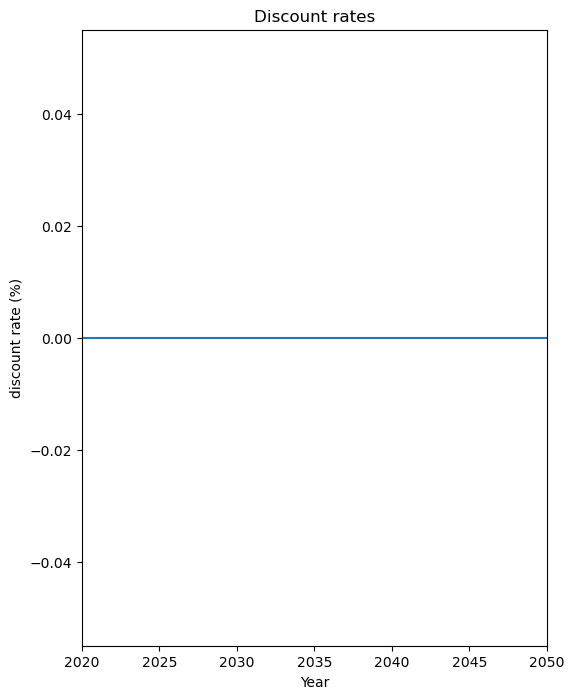

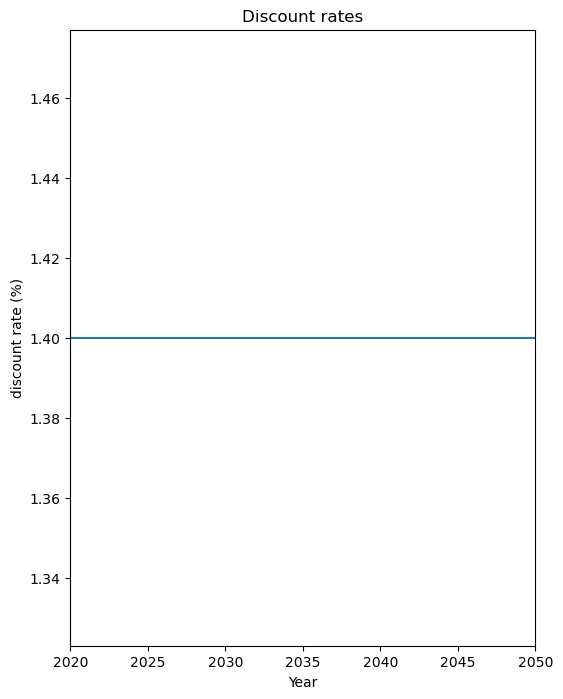

In [34]:
from climada.entity import DiscRates

year_range = np.arange( present_year, future_year + 1)
n_years = len(year_range)
annual_discount_zero = np.zeros(n_years)
annual_discount_stern = np.ones(n_years) * 0.014

# Create discount rates with zero and Stern's discount rates
discount_zero = DiscRates(year_range, annual_discount_zero)
discount_stern = DiscRates(year_range, annual_discount_stern)
# Plot the discount rates
discount_zero.plot(label='Zero Discount Rate')
discount_stern.plot(label='Stern Discount Rate')

Decide on a discount rate

In [35]:
# Create the entity for the present climate scenario
disc_rate = discount_zero  # discount_zero or discount_stern

## 7 - Measures

### 7.1 Make the mappers

Make the exposure mapper

In [36]:
from typing import Optional
# from climada.entity import Exposures

def make_exposure_mapper(
    canopy_df: pd.DataFrame,
    spec_to_fcn: dict,
):
    """
    Returns a function exp_mapper(exposure_present_, year) -> Exposures
    with all other arguments fixed from this scope.
    """

    def exp_mapper( exposure_present: Optional["Exposures"] = None,
                    year: Optional[int] = None
                    ):
        return make_exposures_from_canopy_df(
            canopy_df=canopy_df,
            exposure_present=exposure_present,
            spec_to_fcn=spec_to_fcn,
        )

    return exp_mapper


Try the mapper

In [37]:
# present exposures (baseline)
exp_present = make_exposures_from_canopy_df(
    canopy_df=canopy_crop_dict['present'],
    spec_to_fcn=spec_to_fcn
)
# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# mapper that will (for now) ignore `year` but keeps a compatible signature
# Make the exposures for the second condition (e.g., 'future' or 'alternative')
alternative_name = list(canopy_crop_dict.keys())[1]  # Use the second condition
exp_mapper = make_exposure_mapper(
    canopy_df=canopy_crop_dict[alternative_name],
    spec_to_fcn=spec_to_fcn
)

# later in your code
exp_new = exp_mapper(exposure_present=exp_present)  # year ignored
# Print the Exposures object to verify
print(f"Exposures object for {alternative_name}") 
print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))


Exposures object for 'present' condition:
+----+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+----------------------------------------------+
|    |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   impf_Tmax |   Production (t) |   value | geometry                                     |
|----+-----------------+----------+---------------

Make the impact function set mapper

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 2: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 3: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>]],
      dtype=object)

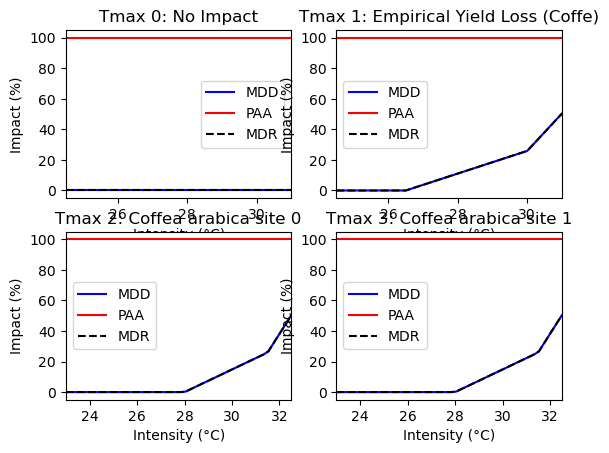

In [38]:
from typing import Optional
import pandas as pd
from climada.entity import ImpactFuncSet

def make_impf_set_mapper(
    canopy_df: pd.DataFrame,
    adjust_fcn,
    imp_fun_set_base: ImpactFuncSet
):
    """
    Returns a function impf_set_mapper(imp_fun_set_base, year) -> ImpactFuncSet
    with all other arguments fixed from this scope.
    """

    def impf_set_mapper(
        imp_fun_set: ImpactFuncSet,
        year: Optional[int] = None
    ) -> ImpactFuncSet:
        return create_adjusted_impact_function_set(
            canopy_df=canopy_df,
            imp_fun_set_base=imp_fun_set_base,
            adjust_fcn=adjust_fcn,
        )

    return impf_set_mapper


adjusted_impf_set = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict[list(canopy_crop_dict.keys())[0]],  # Use the first sheet as the base
    imp_fun_set_base=imp_fun_set_base,
    adjust_fcn=adjust_fcn
)

adjusted_impf_set.plot()

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 2: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 3: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>]],
      dtype=object)

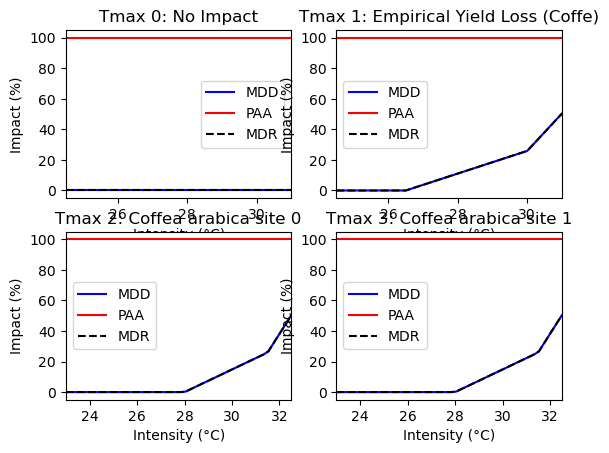

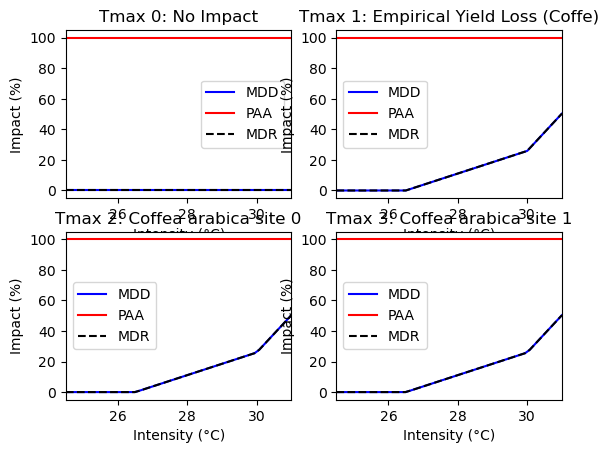

In [39]:
# Get the impact fucntion set for the present compostition
impf_set_present =  create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict['present'],  # Use the first sheet as the base
    adjust_fcn=adjust_fcn
)

# Get the impact fucntion set for the alternatvie
alternative_name = list(canopy_crop_dict.keys())[3]  # Use the second condition
impf_set_mapper = make_impf_set_mapper(canopy_df= canopy_crop_dict[alternative_name],
                                       adjust_fcn = adjust_fcn,
                                       imp_fun_set_base = imp_fun_set_base
)


new_impf_set = impf_set_mapper(impf_set_present)

impf_set_present.plot()
new_impf_set.plot()

### 7.2 Define the measures

In [40]:
from climada.engine.option_appraisal.appraiser import MeasuresAppraiser

# Define the measure
from climada.entity.measures.base import Measure
from climada.entity.measures import MeasureSet
from climada.entity.measures.cost_income import CostIncome

In [41]:
# Define a measure list
meas_list = []

# Make the measures
for comp in canopy_crop_dict.keys():
    if comp == 'present':
        continue
    else:
        # Get the canopy DataFrame for the composition
        canopy_df = canopy_crop_dict[comp]
        # Define the measure
        meas = Measure( haz_type= hazard_type,  # Use the hazard type defined earlier
                        name = comp,
                        # Make the exposures mapper
                        exposures_change = make_exposure_mapper(canopy_df=canopy_df,
                                                                spec_to_fcn=spec_to_fcn
                                                                ),
                        # Make the impact function set mapper
                        impfset_change = make_impf_set_mapper(canopy_df= canopy_df,
                                                                adjust_fcn = adjust_fcn,
                                                                imp_fun_set_base=imp_fun_set_base
                                                                ),
                        # Make the cost income from the canopy_df and costs_df
                        #cost_cashflows_df, _ = make_cashflows_costs(canopy_df, costs_df, years=10)
                        cost_income = make_cost_income_from_canopy_df(canopy_df=canopy_crop_dict[comp],
                                                                        costs_df=costs_df,
                                                                        column='Added'  # 'Added' or 'total'
                                                                    )
                        )
        # Add to the measure list
        meas_list.append(meas)


Try the measures

Exposures object for 'present' condition:
+----+-----------------+----------+------------------+--------------------+--------------------+-----------+-------------+---------------------+--------------------+------------------------+-----------+-------------------------------+--------------------------+------------------+----------------+----------------------+-------------------+----------------------+-------------+------------------+---------+----------------------------------------------+
|    |   Elevation (m) | System   |   Plot size (ha) | Species            | Scientific name    | Role      |   Plants/ha |   Yield (t/ha/year) |   Price-per-tonnes |   Per-tree shading (%) |   site_id |   Per-tree shading (%) scaled |   Shade contribution (%) |   Tree Shade (%) |   canopy_cover |   Plants/ha_baseline |   Added Plants/ha |   Previous Plants/ha |   impf_Tmax |   Production (t) |   value | geometry                                     |
|----+-----------------+----------+---------------

array([[<Axes: title={'center': 'Tmax 0: No Impact'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 1: Empirical Yield Loss (Coffe)'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'Tmax 2: Coffea arabica site 0'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'Tmax 3: Coffea arabica site 1'}, xlabel='Intensity (°C)', ylabel='Impact (%)'>]],
      dtype=object)

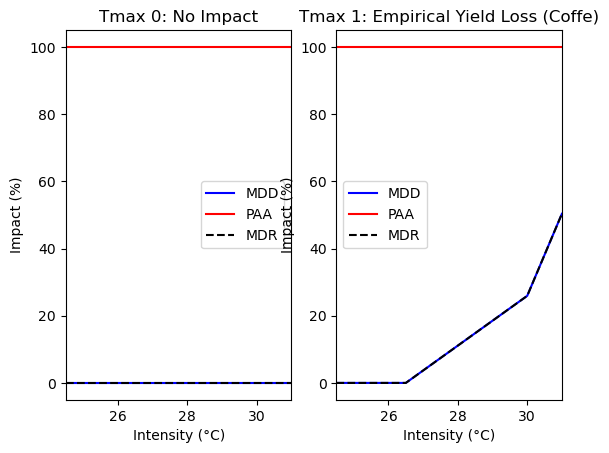

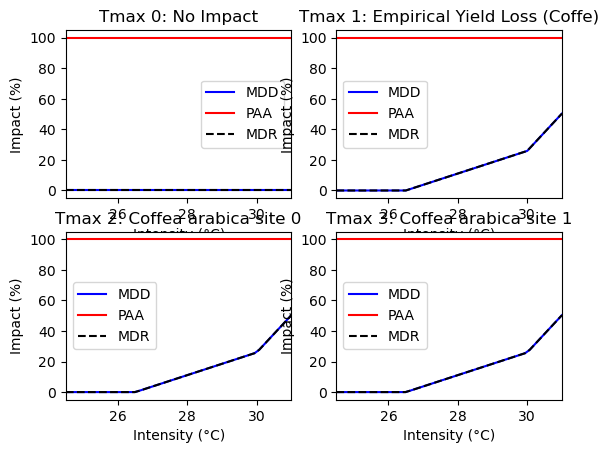

In [42]:
exp_new, impf_set_new, haz_new = meas.apply(exposures = exp_present,
                                            impfset = imp_fun_set_base,
                                            hazard = haz_dict['today']  # Use the hazard for today (or 'present' condition
)


# Print the Exposures object to verify
print("Exposures object for 'present' condition:")
print(tabulate(exp_present.gdf, headers='keys', tablefmt='psql'))

# Print the Exposures object to verify
print(f"Exposures object for {alternative_name}") 
print(tabulate(exp_new.gdf, headers='keys', tablefmt='psql'))

imp_fun_set_base.plot()
impf_set_new.plot()

In [43]:
# Gather all measures in a measure set
meas_set = MeasureSet(measures=meas_list)

## 8 – Cost and Revenue estimates

https://www.usinflationcalculator.com/inflation/coffee-prices-by-year-and-adjust-for-inflation/

### 8.1 - Calculaet impacts 

- To get the AAL and the rp



In [44]:
from calendar import c
from climada.engine import ImpactCalc

# Initialize storage
impacts_dict = {
    'today': {},   # impacts for baseline + measures
    'future': {}
}

exp_dict = copy.deepcopy(impacts_dict)


# Create the impact function set for the present condition
impf_set_present = create_adjusted_impact_function_set(
    canopy_df=canopy_crop_dict['present'],
    adjust_fcn=adjust_fcn,
    imp_fun_set_base=imp_fun_set_base
)
# Create the exposure for the present condition
exp_present = make_exposures_from_canopy_df(
                    canopy_df=canopy_crop_dict['present'],
                    spec_to_fcn=spec_to_fcn
                )

# Loop over climate scenarios
for climate_scenario in ['today', 'future']:
    haz = haz_dict[climate_scenario]
    # Compute the exposure and imapct for each composition
    for comp in canopy_crop_dict.keys():
        if comp == 'present':
            exp = exp_present
            ifs = impf_set_present
        # Compute/store for each adaptation measure
        else:
            meas = meas_set.measures()[comp]
            # Apply the measure → new exposure, new IFS, new hazard
            exp, ifs, _ = meas.apply(exp_present, impf_set_present, haz)

        # Store impact
        impacts_dict[climate_scenario][comp] = ImpactCalc(exp, ifs,haz).impact(save_mat=False)
        # Store exposure
        if climate_scenario == 'today':
            exp_dict[climate_scenario][comp] = exp


Make the basic metrics needed 

In [45]:
npv = make_cashflows_costs(canopy_df=canopy_crop_dict[comp],
                                             costs_df=costs_df,
                                             disc_rate=disc_rate
                                                )[1]['total']

npv
#cost_cashflows_df, npv_dict = make_cashflows_costs(df, costs_df)

0.0

Calculat the costs and impacts for later calcualtions

In [46]:
import pandas as pd
from numpy import interp

rows = []

return_period = 30  # Example return period in years

for comp in impacts_dict['today'].keys():

    # Calculate the net present value (NPV) of costs for the composition
    npv_total = make_cashflows_costs(
        canopy_df=canopy_crop_dict[comp],
        costs_df=costs_df,
        disc_rate=disc_rate
    )[1]['total']

    # Exposure dataframe
    exp_today = exp_dict['today'][comp].gdf

    # Get the total avg. revenue for today
    total_today = exp_today['value'].sum()

    # Get the avg. revenue for  main and secondary crops
    total_main = exp_today.loc[exp_today['Role'] == 'Main', 'value'].sum()
    total_secondary = exp_today.loc[exp_today['Role'] == 'Secondary', 'value'].sum()

    # Get the AAL for today and future - total
    aal_today_total = impacts_dict['today'][comp].aai_agg
    aal_future_total = impacts_dict['future'][comp].aai_agg

    # Get the AAL for today and future - main
    idx_main = exp_today['Role'] == 'Main'
    aal_today_main = impacts_dict['today'][comp].eai_exp[idx_main].sum()
    aal_future_main = impacts_dict['future'][comp].eai_exp[idx_main].sum()

    # Get the AAL for today and future - secondary
    idx_secondary = exp_today['Role'] == 'Secondary'
    aal_today_secondary = impacts_dict['today'][comp].eai_exp[idx_secondary].sum()
    aal_future_secondary = impacts_dict['future'][comp].eai_exp[idx_secondary].sum()

    # Get the worst year impacts (total)
    ifc_today = impacts_dict['today'][comp].calc_freq_curve()
    bad_year_today_total = interp(return_period, ifc_today.return_per, ifc_today.impact)

    ifc_future = impacts_dict['future'][comp].calc_freq_curve()
    bad_year_future_total = interp(return_period, ifc_future.return_per, ifc_future.impact)

    rows.append({
        "Composition": comp,
        "Costs (NPV)": npv_total,

        # Revenues
        "Avg. Revenue – Total (today)": total_today,
        "Avg. Revenue – Main (today)": total_main,
        "Avg. Revenue – Secondary (today)": total_secondary,

        # AAL values
        "_AAL – Total (today)": aal_today_total,
        "_AAL – Main (today)": aal_today_main,
        "_AAL – Secondary (today)": aal_today_secondary,
        "_AAL – Total (future)": aal_future_total,
        "_AAL – Main (future)": aal_future_main,
        "_AAL – Secondary (future)": aal_future_secondary,

        # Bad-year impacts
        "_Bad year impact – Total (today)": bad_year_today_total,
        "_Bad year impact – Total (future)": bad_year_future_total
        # (You could also add bad-year impacts for main/secondary if you interpolate them separately)
    })

df_abs = pd.DataFrame(rows)  # preserves insertion order
print(tabulate(df_abs, headers='keys', tablefmt='psql'))


+----+-----------------+---------------+--------------------------------+-------------------------------+------------------------------------+------------------------+-----------------------+----------------------------+-------------------------+------------------------+-----------------------------+------------------------------------+-------------------------------------+
|    | Composition     |   Costs (NPV) |   Avg. Revenue – Total (today) |   Avg. Revenue – Main (today) |   Avg. Revenue – Secondary (today) |   _AAL – Total (today) |   _AAL – Main (today) |   _AAL – Secondary (today) |   _AAL – Total (future) |   _AAL – Main (future) |   _AAL – Secondary (future) |   _Bad year impact – Total (today) |   _Bad year impact – Total (future) |
|----+-----------------+---------------+--------------------------------+-------------------------------+------------------------------------+------------------------+-----------------------+----------------------------+-------------------------+

Calcualte the estimated future revenue

In [47]:
import pandas as pd

est_values_rows = []

for _, row in df_abs.iterrows():
    npv_total = row["Costs (NPV)"]

    # ==== TOTAL ====
    total_today = row["Avg. Revenue – Total (today)"]
    aal_today_total_pct = (row["_AAL – Total (today)"] / total_today) * 100
    aal_future_total_pct = (row["_AAL – Total (future)"] / total_today) * 100

    bad_year_today_total = total_today - (
        row["_Bad year impact – Total (today)"] - row["_AAL – Total (today)"]
    )
    total_future_total = (total_today / (1 - aal_today_total_pct / 100)) * (1 - aal_future_total_pct / 100)
    bad_year_future_total = total_future_total - (
        (row["_Bad year impact – Total (future)"] - row["_AAL – Total (future)"]) / total_today * total_future_total
    )

    # ==== MAIN ====
    main_today = row["Avg. Revenue – Main (today)"]
    aal_today_main_pct = (row["_AAL – Main (today)"] / main_today) * 100 if main_today > 0 else np.nan
    aal_future_main_pct = (row["_AAL – Main (future)"] / main_today) * 100 if main_today > 0 else np.nan
    main_future = (main_today / (1 - aal_today_main_pct / 100)) * (1 - aal_future_main_pct / 100) 

    # ==== SECONDARY ====
    secondary_today = row["Avg. Revenue – Secondary (today)"]
    aal_today_secondary_pct = (row["_AAL – Secondary (today)"] / secondary_today) * 100 if secondary_today > 0 else np.nan
    aal_future_secondary_pct = (row["_AAL – Secondary (future)"] / secondary_today) * 100 if secondary_today > 0 else  np.nan
    secondary_future = (secondary_today / (1 - aal_today_secondary_pct / 100)) * (1 - aal_future_secondary_pct / 100)

    est_values_rows.append({
        "Composition": row["Composition"],
        "Costs (NPV)": npv_total,

        # Total
        "Avg. Revenue – Total (today)": total_today,
        "AAL % – Total (today)": aal_today_total_pct,
        "AAL % – Total (future)": aal_future_total_pct,
        "Avg. Revenue - Bad Year – Total (today)": bad_year_today_total,
        "Avg. Revenue – Total (future)": total_future_total,
        "Avg. Revenue - Bad Year – Total (future)": bad_year_future_total,

        # Main
        "Avg. Revenue – Main (today)": main_today,
        "AAL % – Main (today)": aal_today_main_pct,
        "AAL % – Main (future)": aal_future_main_pct,
        "Avg. Revenue – Main (future)": main_future,

        # Secondary
        "Avg. Revenue – Secondary (today)": secondary_today,
        "AAL % – Secondary (today)": aal_today_secondary_pct,
        "AAL % – Secondary (future)": aal_future_secondary_pct,
        "Avg. Revenue – Secondary (future)": secondary_future
    })

# Create DataFrame
est_values_df = pd.DataFrame(est_values_rows)
print(tabulate(est_values_df, headers="keys", tablefmt="psql"))


+----+-----------------+---------------+--------------------------------+-------------------------+--------------------------+-------------------------------------------+---------------------------------+--------------------------------------------+-------------------------------+------------------------+-------------------------+--------------------------------+------------------------------------+-----------------------------+------------------------------+-------------------------------------+
|    | Composition     |   Costs (NPV) |   Avg. Revenue – Total (today) |   AAL % – Total (today) |   AAL % – Total (future) |   Avg. Revenue - Bad Year – Total (today) |   Avg. Revenue – Total (future) |   Avg. Revenue - Bad Year – Total (future) |   Avg. Revenue – Main (today) |   AAL % – Main (today) |   AAL % – Main (future) |   Avg. Revenue – Main (future) |   Avg. Revenue – Secondary (today) |   AAL % – Secondary (today) |   AAL % – Secondary (future) |   Avg. Revenue – Secondary (future

Estimate the net present value of the revenue streams

In [48]:
import numpy as np
import pandas as pd

years = future_year - present_year + 1
inflation_rate = 0.02  # 2% annual

npv_rows = []

# Calculate NPV for each role in each composition
for _, row in est_values_df.iterrows():
    role_data = {}
    role_data["Composition"] = row["Composition"]

    for role in ["Total", "Main", "Secondary"]:
        rev_today = row.get(f"Avg. Revenue – {role} (today)", 0)
        rev_future = row.get(f"Avg. Revenue – {role} (future)", 0)

        if pd.isna(rev_today) or pd.isna(rev_future) or rev_today == 0:
            role_data[f"Revenue (NPV) – {role}"] = 0
            continue

        # Linear interpolation between today and future over 'years'
        yearly_revenues = np.linspace(rev_today, rev_future, years)

        # Apply inflation rate (or other growth parameter)
        yearly_revenues = yearly_revenues * (1 + inflation_rate) ** np.arange(1, years + 1)

        # Discount to get NPV
        npv = disc_rate.net_present_value(present_year, future_year, yearly_revenues)
        role_data[f"Revenue (NPV) – {role}"] = npv

    npv_rows.append(role_data)

df_npv = pd.DataFrame(npv_rows)
print(df_npv)


       Composition  Revenue (NPV) – Total  Revenue (NPV) – Main  \
0          present          110178.669697         110178.669697   
1       more_trees          110185.617387         110185.617387   
2  even_more_trees          108731.111282         108731.111282   
3         no_trees           96075.549727          96075.549727   

   Revenue (NPV) – Secondary  
0                          0  
1                          0  
2                          0  
3                          0  


Calculate the net and the benefit of comparing the present 

In [49]:
df_cb_metrics = est_values_df.merge(df_npv, on="Composition", how="left")
store_columns = [
    "Composition",
    "Costs (NPV)",
    "Revenue (NPV) – Total",
    #"Revenue (NPV) – Main",
    #"Revenue (NPV) – Secondary",
    "Avg. Revenue – Total (today)",
    "Avg. Revenue – Total (future)",
    "Avg. Revenue - Bad Year – Total (today)",
    "Avg. Revenue - Bad Year – Total (future)"
]
df_cb_metrics = df_cb_metrics[store_columns]
# Calculate Net Present Value (NPV) of the net benefits
df_cb_metrics["Net (NPV)"] = df_cb_metrics["Revenue (NPV) – Total"] - df_cb_metrics["Costs (NPV)"]

# Calculate the benefit-cost ratio (BCR) given the Composition "present" as the baseline
baseline_net = df_cb_metrics.loc[df_cb_metrics['Composition'] == 'present', 'Net (NPV)'].values[0]
df_cb_metrics['Benefit'] = df_cb_metrics['Net (NPV)'] - baseline_net
df_cb_metrics['BCR'] = df_cb_metrics['Benefit'] / df_cb_metrics['Costs (NPV)']
# Place the 'Net (NPV)' after Revenue (NPV) – Total and the benefit and NCR after Net 
df_cb_metrics = df_cb_metrics[["Composition", "Costs (NPV)", "Revenue (NPV) – Total", "Net (NPV)",
                                "Benefit", "BCR",
                                "Avg. Revenue – Total (today)", "Avg. Revenue – Total (future)",
                                "Avg. Revenue - Bad Year – Total (today)", "Avg. Revenue - Bad Year – Total (future)"]]
# Print the final metrics DataFrame
print(tabulate(df_cb_metrics, headers='keys', tablefmt='psql'))

+----+-----------------+---------------+-------------------------+-------------+-----------+--------------+--------------------------------+---------------------------------+-------------------------------------------+--------------------------------------------+
|    | Composition     |   Costs (NPV) |   Revenue (NPV) – Total |   Net (NPV) |   Benefit |          BCR |   Avg. Revenue – Total (today) |   Avg. Revenue – Total (future) |   Avg. Revenue - Bad Year – Total (today) |   Avg. Revenue - Bad Year – Total (future) |
|----+-----------------+---------------+-------------------------+-------------+-----------+--------------+--------------------------------+---------------------------------+-------------------------------------------+--------------------------------------------|
|  0 | present         |         13392 |                110179   |     96786.7 |     0     |    0         |                        2628    |                         2484.71 |                                  

As a final we add the biodiversity metric

## 9 – Risk and CB Analysis (with uncertainties)

## 10 – Risk and CB Analysis (new cost benefit module)